# Ejercicio 1 — Predicción de calidad de vino tinto (`winequality-red.csv`)

Dataset de vinos rojos basado en datos físico-químicos y una métrica de calidad de vino.
Más info: [Kaggle / UCI](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009).
Queremos predecir la **calidad del vino** usando sus atributos físico-químicos.

## Parte 1 — Estudio de variables

1. Leer el dataset como un `DataFrame` de Pandas.
2. Analizar nombres, qué miden, tipo de variable (incluido el target), rango y distribución (histograma).
3. Realizar matriz de correlación. ¿Qué variables están correlacionadas? ¿Cuáles correlacionan con la calidad?

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (mean_absolute_error, r2_score,
                             root_mean_squared_error,
                             mean_absolute_percentage_error)
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.exceptions import ConvergenceWarning
from optuna.samplers import GPSampler

sns.set()

## 1. Lectura del dataset y estudio de variables

In [32]:
wine_df = pd.read_csv("./datasets/winequality-red.csv")

In [33]:
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [34]:
wine_df.shape

(1599, 12)

In [35]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [36]:
wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [37]:
wine_df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [38]:
wine_df.duplicated().sum()

240

In [39]:
wine_df = wine_df.drop_duplicates().reset_index(drop=True)
print(f"Shape post drop_duplicates: {wine_df.shape}")

Shape post drop_duplicates: (1359, 12)


### Descripción de variables

Según la documentación de UCI / Cortez et al. (2009), las 11 variables predictoras son medidas físico-químicas obtenidas en laboratorio y `quality` es la mediana de evaluaciones sensoriales hechas por al menos 3 catadores (score entero de 0 a 10).

| Variable | Unidad | Descripción |
|---|---|---|
| `fixed acidity` | g(ácido tartárico)/dm³ | Ácidos fijos del vino (no se evaporan fácilmente). |
| `volatile acidity` | g(ácido acético)/dm³ | Ácido acético; en niveles altos genera sabor desagradable a vinagre. |
| `citric acid` | g/dm³ | Aporta "frescura" y sabor a los vinos; en pequeñas cantidades. |
| `residual sugar` | g/dm³ | Azúcar remanente tras la fermentación. Vinos secos < 4 g/dm³. |
| `chlorides` | g(NaCl)/dm³ | Cantidad de sal en el vino. |
| `free sulfur dioxide` | mg/dm³ | SO₂ libre; previene oxidación y crecimiento microbiano. |
| `total sulfur dioxide` | mg/dm³ | SO₂ total (libre + ligado). |
| `density` | g/cm³ | Densidad; depende del contenido de alcohol y azúcar. |
| `pH` | – | Acidez/basicidad (0 muy ácido, 14 muy básico). Vinos típicamente 3–4. |
| `sulphates` | g(K₂SO₄)/dm³ | Aditivo antimicrobiano/antioxidante. |
| `alcohol` | % vol. | Porcentaje de alcohol en volumen. |
| `quality` (target) | score 0–10 | Mediana de evaluación de catadores. Variable **entera ordinal**. |

**Tipos**: las 11 features son continuas (`float64`). El target `quality` es entero (`int64`), ordinal — se puede tratar como problema de **regresión** o de **clasificación multiclase**.

### Distribución de variables (histogramas)

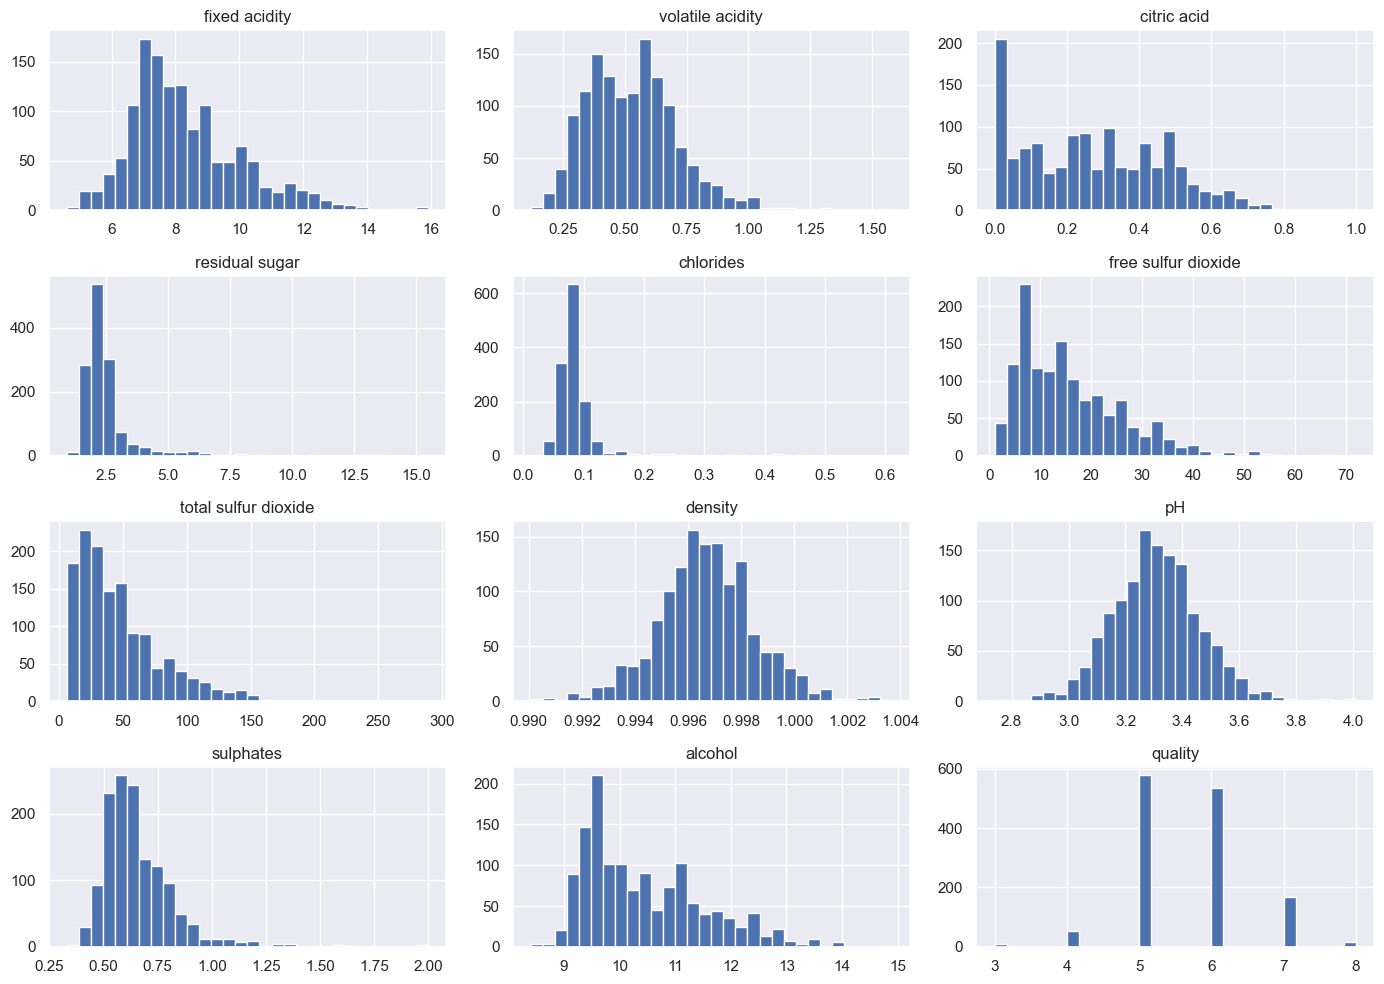

In [40]:
wine_df.hist(bins=30, figsize=(14, 10))
plt.tight_layout()
plt.show()

Observaciones de las distribuciones:

- `fixed acidity`, `volatile acidity`, `citric acid`, `sulphates`, `alcohol` y `pH` se distribuyen de forma aproximadamente unimodal, con cierto sesgo a derecha.
- `residual sugar`, `chlorides`, `free sulfur dioxide` y `total sulfur dioxide` tienen distribuciones fuertemente sesgadas a la derecha, con outliers altos.
- `density` y `pH` se ven bastante simétricas (aprox. normales).

### Distribución del target (`quality`)

In [41]:
wine_df["quality"].value_counts().sort_index()

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

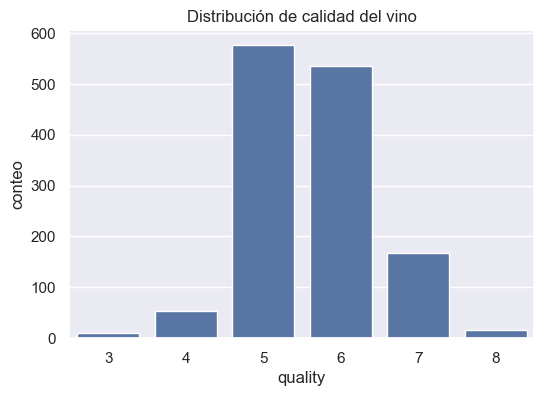

In [42]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x="quality", data=wine_df, ax=ax)
ax.set_title("Distribución de calidad del vino")
ax.set_xlabel("quality")
ax.set_ylabel("conteo")
plt.show()

El target está **fuertemente desbalanceado**:

- Solo aparecen valores `quality ∈ {3, 4, 5, 6, 7, 8}`; los extremos teóricos (0–2 y 9–10) no existen en el dataset.
- Las clases 5 y 6 concentran la gran mayoría de las observaciones.
- Las clases 3 y 8 son raras (<20 muestras cada una).

Esto va a tener implicancias para el modelado: cualquier clasificador multiclase tenderá a predecir 5 o 6, y conviene considerar métricas que penalicen el desbalance (F1 macro, exactitud balanceada) o tratar el problema como regresión.

### Matriz de correlación

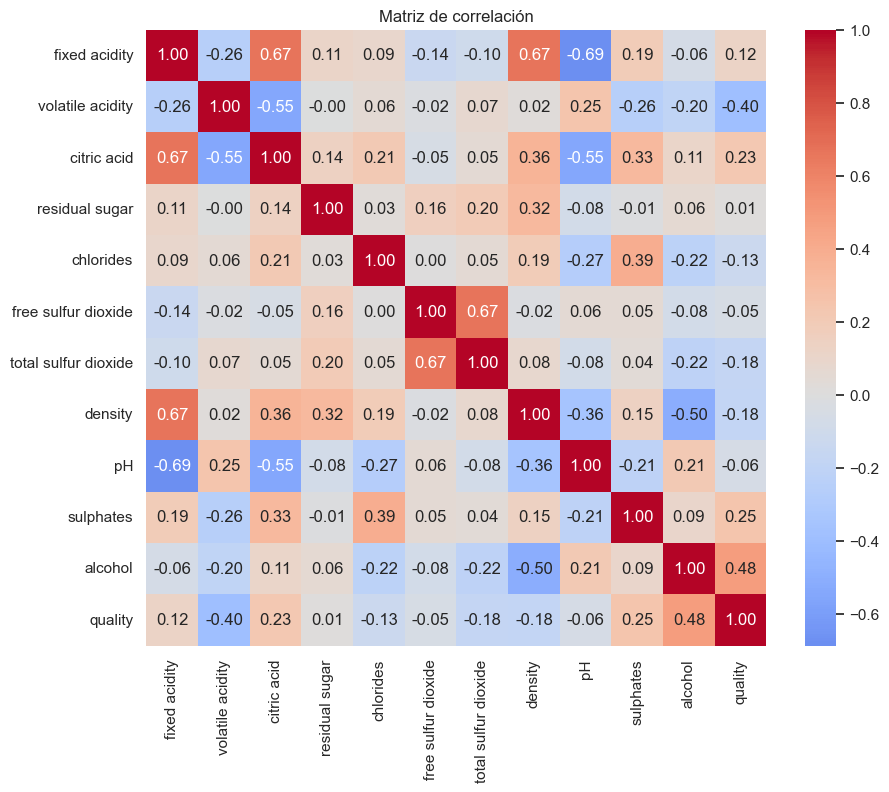

In [43]:
corr = wine_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlación")
plt.show()

In [44]:
wine_df.corr()["quality"].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64

**Correlaciones entre features** (las más fuertes):

- `fixed acidity` ↔ `citric acid`: positiva fuerte (~+0.67) — ambos miden acidez relacionada.
- `fixed acidity` ↔ `density`: positiva (~+0.67) — más ácidos no volátiles aportan masa al líquido.
- `fixed acidity` ↔ `pH`: negativa fuerte (~−0.68) — más ácido implica menor pH (consistente con química).
- `citric acid` ↔ `volatile acidity`: negativa (~−0.55).
- `citric acid` ↔ `pH`: negativa (~−0.54).
- `free sulfur dioxide` ↔ `total sulfur dioxide`: positiva fuerte (~+0.67) — el libre es subconjunto del total.
- `alcohol` ↔ `density`: negativa fuerte (~−0.50) — el alcohol es menos denso que el agua.

**Correlaciones con `quality`** (target):

- Positivas: `alcohol` (≈ +0.48, **la más fuerte**), `sulphates` (~+0.25), `citric acid` (~+0.23), `fixed acidity` (~+0.12).
- Negativas: `volatile acidity` (~−0.39), `total sulfur dioxide` (~−0.19), `density` (~−0.17), `chlorides` (~−0.13), `pH` (~−0.06).
- `residual sugar` y `free sulfur dioxide` son casi independientes de la calidad (|corr| < 0.05).

**Conclusión**: el predictor lineal más fuerte de la calidad es `alcohol`, seguido de `volatile acidity` (que correlaciona negativamente). Esto es consistente con la consigna posterior, que pide modelar `quality` a partir del nivel de alcohol.

In [45]:
X_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
          'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
          'pH', 'sulphates', 'alcohol']

X = wine_df.loc[:, X_cols]
# Y como variable a predecir a Quality
y = wine_df.loc[:, 'quality']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [47]:
pt = PowerTransformer(method="yeo-johnson", standardize=True)
X_train = pt.fit_transform(X_train)
X_test = pt.transform(X_test)

In [48]:
def objective(trial):
    kernel = trial.suggest_categorical("kernel", ["rbf", "poly"])
    C = trial.suggest_float("C", 1e-1, 1e3, log=True)
    gamma_mode = trial.suggest_categorical("gamma_mode", ["scale", "float"])
    if gamma_mode == "float":
        gamma = trial.suggest_float("gamma", 1e-4, 1.0, log=True)
    else:
        gamma = "scale"
    epsilon = trial.suggest_float("epsilon", 1e-2, 0.5, log=True)

    params = {"kernel": kernel, "C": C, "gamma": gamma,
              "epsilon": epsilon, "cache_size": 500, "max_iter": 200000}
    if kernel == "poly":
        params["degree"] = trial.suggest_int("degree", 2, 3)

    model = make_pipeline(StandardScaler(), SVR(**params))
    scores = cross_val_score(model, X_train, y_train, cv=5,
                             scoring="neg_mean_absolute_error", n_jobs=-1)
    return scores.mean()


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize",
                            sampler=GPSampler(seed=42, warn_independent_sampling=False))
study.enqueue_trial({"kernel": "rbf", "C": 1.0,
                     "gamma_mode": "float", "gamma": 0.1,
                     "epsilon": 0.1})
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Mejor MAE (CV): {-study.best_value:.4f}")
print(f"Mejores hiperparámetros: {study.best_params}")

best_params = dict(study.best_params)
gm = best_params.pop("gamma_mode")
if gm == "scale":
    best_params.pop("gamma", None)
    best_params["gamma"] = "scale"
best_model = make_pipeline(StandardScaler(), SVR(**best_params, cache_size=500, max_iter=200000))
best_model.fit(X_train, y_train)

/var/folders/6k/5h802l7x7nl4z6q7y2xjf4qc0000gn/T/ipykernel_29176/241001913.py:24: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler=GPSampler(seed=42, warn_independent_sampling=False))


  0%|          | 0/100 [00:00<?, ?it/s]

/Users/francomorero/PycharmProjects/franco/ceia-trabajos/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=200000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/francomorero/PycharmProjects/franco/ceia-trabajos/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=200000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/francomorero/PycharmProjects/franco/ceia-trabajos/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=200000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/francomorero/PycharmProjects/franco/ceia-trabajos/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=200000).  Consider

Mejor MAE (CV): 0.4795
Mejores hiperparámetros: {'kernel': 'rbf', 'C': 0.5626036868269442, 'gamma_mode': 'scale', 'epsilon': 0.011722197438368255}


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr',
                 SVR(C=0.5626036868269442, cache_size=500,
                     epsilon=0.011722197438368255, max_iter=200000))])

In [49]:
study.best_params

{'kernel': 'rbf',
 'C': 0.5626036868269442,
 'gamma_mode': 'scale',
 'epsilon': 0.011722197438368255}

In [50]:
y_pred = best_model.predict(X_test)

In [51]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE de testeo fue: {mae}")
print(f"RMSE de testeo fue: {rmse}")
print(f"MAPE de testeo fue: {mape}")
print(f"R2 de testeo fue: {r2}")

MAE de testeo fue: 0.47613715041033766
RMSE de testeo fue: 0.6455524646436941
MAPE de testeo fue: 0.08776480225093138
R2 de testeo fue: 0.3787765095765786


### Comparación: tuneo con MAE vs MSE

Repetimos la búsqueda con `neg_mean_squared_error` como scoring para ver si la elección de la métrica de optimización cambia los hiperparámetros y/o el desempeño final.

In [52]:
def objective_mse(trial):
    kernel = trial.suggest_categorical("kernel", ["rbf", "poly"])
    C = trial.suggest_float("C", 1e-1, 1e3, log=True)
    gamma_mode = trial.suggest_categorical("gamma_mode", ["scale", "float"])
    if gamma_mode == "float":
        gamma = trial.suggest_float("gamma", 1e-4, 1.0, log=True)
    else:
        gamma = "scale"
    epsilon = trial.suggest_float("epsilon", 1e-2, 0.5, log=True)

    params = {"kernel": kernel, "C": C, "gamma": gamma,
              "epsilon": epsilon, "cache_size": 500, "max_iter": 200000}
    if kernel == "poly":
        params["degree"] = trial.suggest_int("degree", 2, 3)

    model = make_pipeline(StandardScaler(), SVR(**params))
    scores = cross_val_score(model, X_train, y_train, cv=5,
                             scoring="neg_mean_squared_error", n_jobs=-1)
    return scores.mean()


study_mse = optuna.create_study(direction="maximize",
                                sampler=GPSampler(seed=42, warn_independent_sampling=False))
study_mse.enqueue_trial({"kernel": "rbf", "C": 1.0,
                         "gamma_mode": "float", "gamma": 0.1,
                         "epsilon": 0.1})
study_mse.optimize(objective_mse, n_trials=100, show_progress_bar=True)

print(f"Mejor MSE (CV): {-study_mse.best_value:.4f}")
print(f"Mejores hiperparámetros: {study_mse.best_params}")

best_params_mse = dict(study_mse.best_params)
gm = best_params_mse.pop("gamma_mode")
if gm == "scale":
    best_params_mse.pop("gamma", None)
    best_params_mse["gamma"] = "scale"
best_model_mse = make_pipeline(StandardScaler(), SVR(**best_params_mse, cache_size=500, max_iter=200000))
best_model_mse.fit(X_train, y_train)

/var/folders/6k/5h802l7x7nl4z6q7y2xjf4qc0000gn/T/ipykernel_29176/1984540282.py:23: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler=GPSampler(seed=42, warn_independent_sampling=False))


  0%|          | 0/100 [00:00<?, ?it/s]

/Users/francomorero/PycharmProjects/franco/ceia-trabajos/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=200000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/francomorero/PycharmProjects/franco/ceia-trabajos/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=200000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/francomorero/PycharmProjects/franco/ceia-trabajos/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=200000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/francomorero/PycharmProjects/franco/ceia-trabajos/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=200000).  Consider

Mejor MSE (CV): 0.4224
Mejores hiperparámetros: {'kernel': 'rbf', 'C': 0.6431495255717682, 'gamma_mode': 'scale', 'epsilon': 0.0822750078489024}


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr',
                 SVR(C=0.6431495255717682, cache_size=500,
                     epsilon=0.0822750078489024, max_iter=200000))])

In [53]:
y_pred_mse = best_model_mse.predict(X_test)

mae_mse  = mean_absolute_error(y_test, y_pred_mse)
rmse_mse = root_mean_squared_error(y_test, y_pred_mse)
mape_mse = mean_absolute_percentage_error(y_test, y_pred_mse)
r2_mse   = r2_score(y_test, y_pred_mse)

print("Modelo tuneado con MSE — métricas de test:")
print(f"  MAE:  {mae_mse:.4f}")
print(f"  RMSE: {rmse_mse:.4f}")
print(f"  MAPE: {mape_mse:.4f}")
print(f"  R2:   {r2_mse:.4f}")

Modelo tuneado con MSE — métricas de test:
  MAE:  0.4789
  RMSE: 0.6431
  MAPE: 0.0887
  R2:   0.3835


In [54]:
comparison = pd.DataFrame({
    "Tuneo MAE": [mae, rmse, mape, r2],
    "Tuneo MSE": [mae_mse, rmse_mse, mape_mse, r2_mse],
}, index=["MAE", "RMSE", "MAPE", "R2"])
comparison

,Tuneo MAE,Tuneo MSE
MAE,0.476137,0.478897
RMSE,0.645552,0.643071
MAPE,0.087765,0.088720
R2,0.378777,0.383544


Notas sobre la comparación:

- **MAE como objetivo** penaliza menos los outliers — tiende a elegir modelos con mediana de error baja.
- **MSE como objetivo** penaliza cuadráticamente — castiga errores grandes, suele preferir modelos con menor varianza de error.
- Si los hiperparámetros óptimos difieren entre ambos, indica que el espacio tiene trade-offs entre sesgo y varianza.
- En este dataset (`quality` entero 3–8 con clases desbalanceadas), los errores grandes son raros, por lo que MAE y MSE suelen converger a soluciones similares; chequear `comparison` para confirmar.

## Parte 3 — Árbol de Regresión con Optuna

Se construyen varios árboles de regresión (`DecisionTreeRegressor`) variando hiperparámetros mediante búsqueda bayesiana (Optuna + GPSampler). Se evalúan con validación cruzada de 5 folds usando MAE como métrica de optimización y se retiene el mejor modelo.

In [55]:
from sklearn.tree import DecisionTreeRegressor

In [56]:
def objective_tree(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 1, 30),
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "friedman_mse", "absolute_error"]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.1),
        "random_state": 42,
    }
    model = DecisionTreeRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5,
                             scoring="neg_mean_absolute_error", n_jobs=-1)
    return scores.mean()


optuna.logging.set_verbosity(optuna.logging.WARNING)
study_tree = optuna.create_study(direction="maximize", sampler=GPSampler(seed=42))
study_tree.optimize(objective_tree, n_trials=100, show_progress_bar=True)

print(f"Mejor MAE (CV): {-study_tree.best_value:.4f}")
print(f"Mejores hiperparámetros: {study_tree.best_params}")

/var/folders/6k/5h802l7x7nl4z6q7y2xjf4qc0000gn/T/ipykernel_29176/4255357559.py:17: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  study_tree = optuna.create_study(direction="maximize", sampler=GPSampler(seed=42))


  0%|          | 0/100 [00:00<?, ?it/s]

Mejor MAE (CV): 0.4747
Mejores hiperparámetros: {'max_depth': 3, 'criterion': 'absolute_error', 'min_samples_split': 2, 'min_samples_leaf': 12, 'ccp_alpha': 0.0}


In [57]:
best_tree = DecisionTreeRegressor(**study_tree.best_params)
best_tree.fit(X_train, y_train)
y_pred_tree = best_tree.predict(X_test)

mae_tree  = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = root_mean_squared_error(y_test, y_pred_tree)
mape_tree = mean_absolute_percentage_error(y_test, y_pred_tree)
r2_tree   = r2_score(y_test, y_pred_tree)

print(f"MAE:  {mae_tree:.4f}")
print(f"RMSE: {rmse_tree:.4f}")
print(f"MAPE: {mape_tree:.4f}")
print(f"R²:   {r2_tree:.4f}")

MAE:  0.4743
RMSE: 0.7351
MAPE: 0.0861
R²:   0.1944


In [58]:
comparison_tree = pd.DataFrame({
    "Modelo": ["SVR (tuneo MAE)", "SVR (tuneo MSE)", "DecisionTreeRegressor"],
    "MAE":  [mae,     mae_mse,  mae_tree],
    "RMSE": [rmse,    rmse_mse, rmse_tree],
    "MAPE": [mape,    mape_mse, mape_tree],
    "R²":   [r2,      r2_mse,   r2_tree],
})
comparison_tree

,Modelo,MAE,RMSE,MAPE,R²
0,SVR (tuneo MAE),0.476137,0.645552,0.087765,0.378777
1,SVR (tuneo MSE),0.478897,0.643071,0.088720,0.383544
2,DecisionTreeRegressor,0.474265,0.735147,0.086056,0.194374


### Visualización del árbol óptimo

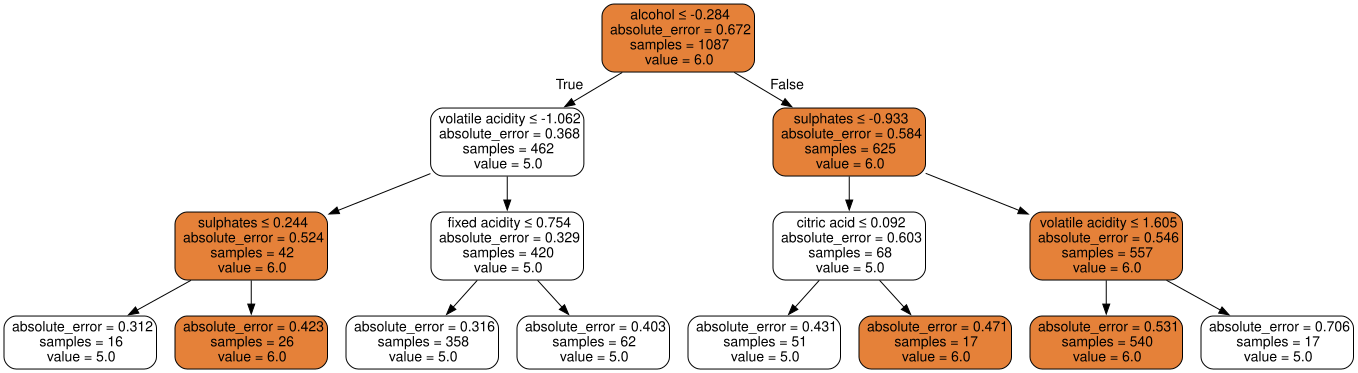

Exception ignored in: <function ResourceTracker.__del__ at 0x109df0860>
Traceback (most recent call last):
  File "/Users/francomorero/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/francomorero/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/francomorero/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107b48860>
Traceback (most recent call last):
  File "/Users/francomorero/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/francomorero/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3

In [61]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    best_tree,
    out_file=None,
    feature_names=X_cols,
    filled=True,
    rounded=True,
    special_characters=True,
    precision=3,
)
graphviz.Source(dot_data)

El arbol resulta muy facil de explicar, pero el modelo de SVM es mejor, porque al usar un kernel y hacer un corte en una dimensionalidad mayor, explica mejor los datos, que el arbol que solo hace cortes que optimizan de forma local